In [45]:
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["font.family"]        = "Malgun Gothic"

In [46]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 20)

%matplotlib inline
plt.rcParams["figure.figsize"]    = (12, 5)
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

PALETTE = {
    "primary": "#378ADD",
    "success": "#1D9E75",
    "danger":  "#D85A30",
    "warning": "#BA7517",
    "gray":    "#888780",
}
COLOR_UP   = PALETTE["success"]
COLOR_DOWN = PALETTE["danger"]

In [47]:
from src.loader import load_raw, print_summary

df_raw = load_raw()
print_summary(df_raw)

  데이터셋 기본 정보
  총 행   : 4,150
  총 컬럼 : 12
  컬럼 목록  : ['Rank', 'Coin Name', 'Symbol', 'Price', '1h', '24h', '7d', '30d', '24h Volume', 'Circulating Supply', 'Total Supply', 'Market Cap']

  결측치 현황:
    1h                       :    95 (2.3%)
    7d                       :     2 (0.0%)
    30d                      :    57 (1.4%)


In [48]:
df_raw.head(10)

,Rank,Coin Name,Symbol,Price,1h,24h,7d,30d,24h Volume,Circulating Supply,Total Supply,Market Cap
0,1,Bitcoin,BTC,"36,456.94",0.40%,-1.70%,1.00%,18.40%,"$22,801,222,945.00","19,549,806",21 Million,"$712,726,163,003.00"
1,2,Ethereum,ETH,"2,027.60",0.50%,1.40%,1.00%,20.70%,"$26,845,710,464.00","120,249,015",120 Million,"$243,488,187,281.00"
2,3,Tether,USDT,1.00,0.10%,-0.30%,-0.10%,-0.10%,"$47,122,466,339.00","88,308,652,879",88.3 Billion,"$88,027,617,310.00"
3,4,BNB,BNB,231.63,-0.10%,-12.60%,-8.00%,5.40%,"$3,715,265,116.00","153,856,150",154 Million,"$35,716,332,862.00"
4,5,XRP,XRP,0.59,0.10%,-1.90%,-6.90%,12.10%,"$1,339,890,506.00","53,718,306,475",100 Billion,"$31,863,926,051.00"
5,6,USDC,USDC,1.00,0.00%,-0.40%,0.00%,0.00%,"$16,458,242,430.00","24,264,590,094",24.3 Billion,"$24,120,082,159.00"
6,7,Solana,SOL,54.97,0.60%,-0.60%,-11.40%,87.90%,"$2,374,980,324.00","423,104,320",563 Million,"$23,258,087,884.00"
7,8,Lido Staked Ether,STETH,"2,023.81",0.40%,1.50%,0.90%,20.70%,"$17,625,537.00","9,107,771",9.11 Million,"$18,435,320,434.00"
8,9,Cardano,ADA,0.37,0.10%,-1.60%,0.70%,40.10%,"$373,277,046.00","34,964,744,027",45 Billion,"$12,903,956,719.00"
9,10,Dogecoin,DOGE,0.07,0.10%,-2.30%,0.10%,14.90%,"$957,225,658.00","141,935,606,384",142 Billion,"$10,532,913,776.00"


In [49]:
print(df_raw.dtypes)

Rank                   int64
Coin Name             object
Symbol                object
Price                 object
1h                    object
24h                   object
7d                    object
30d                   object
24h Volume            object
Circulating Supply    object
Total Supply          object
Market Cap            object
dtype: object


In [50]:
missing     = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
pd.DataFrame({"결측 수": missing, 
              "결측률(%)": missing_pct}).query("`결측 수` > 0")

,결측 수,결측률(%)
1h,95,2.3000
7d,2,0.0000
30d,57,1.4000


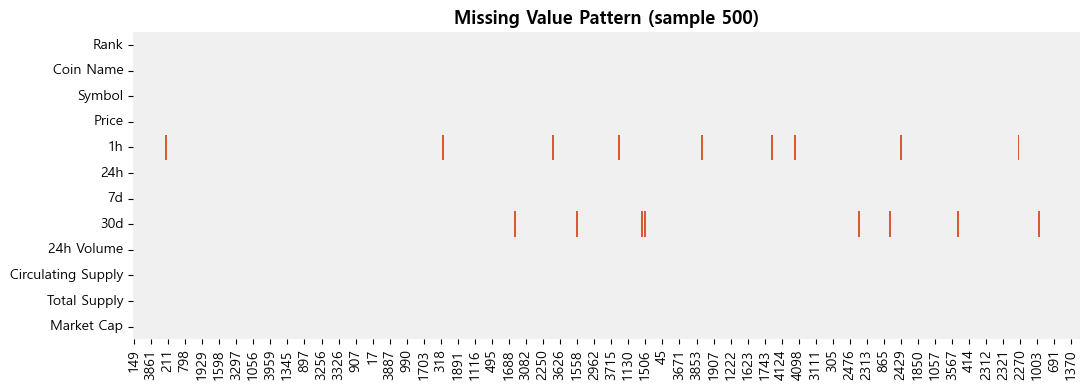

In [51]:
fig, ax = plt.subplots(figsize=(11, 4))
sample = df_raw.sample(500, random_state=42)
sns.heatmap(sample.isnull().T.astype(int), ax=ax, cbar=False,
            cmap=["#f0f0f0", PALETTE["danger"]], yticklabels=df_raw.columns)
ax.set_title("Missing Value Pattern (sample 500)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [52]:
from src.preprocessor import preprocess, print_preprocess_summary

df = preprocess(df_raw)
print_preprocess_summary(df)


[ 결과 요약 ]
            price           volume        market_cap    1h_pct   24h_pct    7d_pct     30d_pct
count   2424.0000        3666.0000         3740.0000 3603.0000 3698.0000 3696.0000   3641.0000
mean     302.0000    41444503.4700    385746655.9000    0.1900    0.1700    5.3900    115.7800
std     3700.4900  1015837309.0400  12445779922.0800    5.1100   19.6900  109.4500   3951.9100
min        0.0100           0.0100            0.0200  -41.8000  -90.9000  -97.0000    -99.5000
25%        0.0200        2877.0000       230530.2500   -0.3000   -4.5000   -9.2000     -1.6000
50%        0.1100       43602.0000      1591722.0000    0.0000   -1.1000   -1.9000     14.1000
75%        0.7500      392319.7500     12579305.2500    0.5000    1.7000    4.9000     42.5000
max   109861.0000 47122466339.0000 712726163003.0000  215.5000  500.8000 5833.5000 237566.7000

  스테이블코인  : 8
  Large Cap    : 55
  Mid Cap      : 243
  Small Cap    : 3442
  유동성 경고   : 235
  수익률 이상치 : 23


In [53]:
cols = ["price","1h_pct","24h_pct","7d_pct","30d_pct",
        "volume","market_cap","is_stablecoin","cap_tier","vol_mcap_ratio"]
df[cols].head(10)

,price,1h_pct,24h_pct,7d_pct,30d_pct,volume,market_cap,is_stablecoin,cap_tier,vol_mcap_ratio
0,36456.9400,0.4000,-1.7000,1.0000,18.4000,22801222945.0000,712726163003.0000,False,Large,0.0320
1,2027.6000,0.5000,1.4000,1.0000,20.7000,26845710464.0000,243488187281.0000,False,Large,0.1103
2,1.0000,0.1000,-0.3000,-0.1000,-0.1000,47122466339.0000,88027617310.0000,True,Large,0.5353
3,231.6300,-0.1000,-12.6000,-8.0000,5.4000,3715265116.0000,35716332862.0000,False,Large,0.1040
4,0.5900,0.1000,-1.9000,-6.9000,12.1000,1339890506.0000,31863926051.0000,False,Large,0.0421
5,1.0000,0.0000,-0.4000,0.0000,0.0000,16458242430.0000,24120082159.0000,True,Large,0.6823
6,54.9700,0.6000,-0.6000,-11.4000,87.9000,2374980324.0000,23258087884.0000,False,Large,0.1021
7,2023.8100,0.4000,1.5000,0.9000,20.7000,17625537.0000,18435320434.0000,False,Large,0.0010
8,0.3700,0.1000,-1.6000,0.7000,40.1000,373277046.0000,12903956719.0000,False,Large,0.0289
9,0.0700,0.1000,-2.3000,0.1000,14.9000,957225658.0000,10532913776.0000,False,Large,0.0909


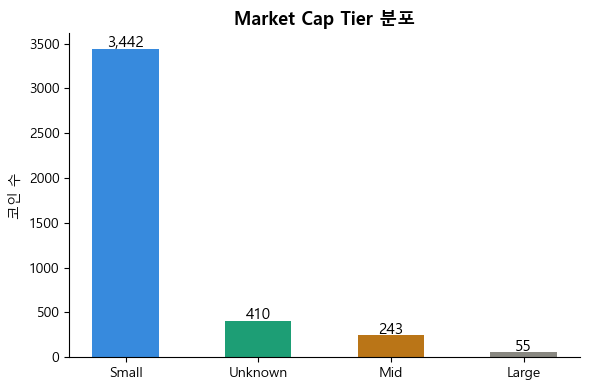

In [54]:
tier = df["cap_tier"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(tier.index, tier.values,
              color=[PALETTE["primary"], PALETTE["success"],
                     PALETTE["warning"], PALETTE["gray"]],
              edgecolor="none", width=0.5)
for bar, val in zip(bars, tier.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{val:,}", ha="center", fontsize=11)
ax.set_title("Market Cap Tier 분포", fontsize=13, fontweight="bold")
ax.set_ylabel("코인 수")
plt.tight_layout()
plt.show()

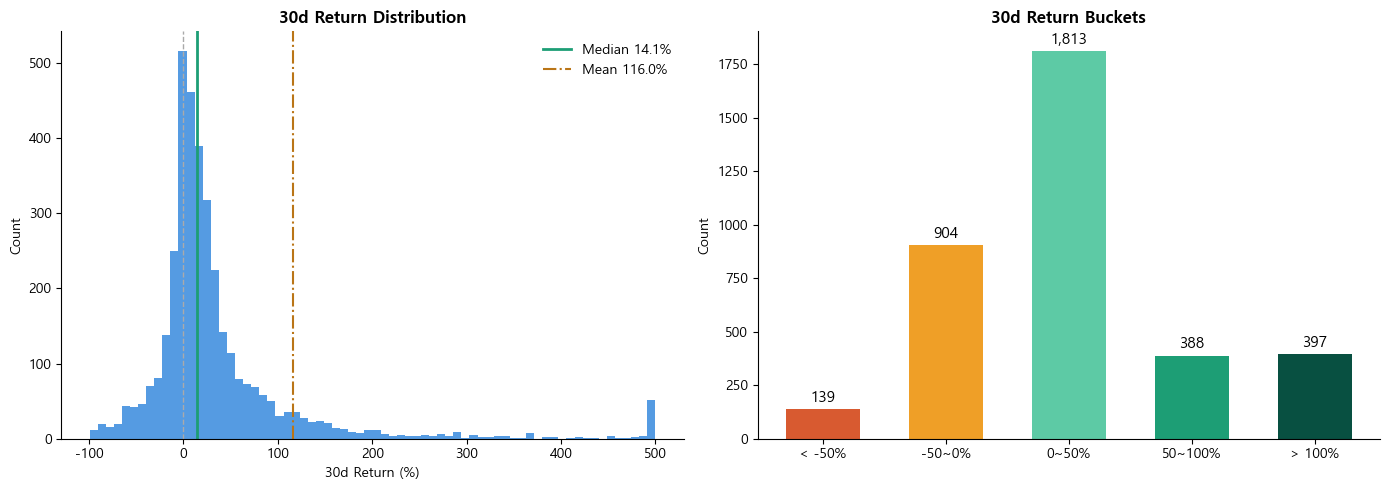

In [55]:
from src.eda import return_distribution

series  = df[~df["is_stablecoin"]]["30d_pct"].dropna()
clipped = series.clip(-100, 500)
dist    = return_distribution(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(clipped, bins=70, color=PALETTE["primary"], edgecolor="none", alpha=0.85)
axes[0].axvline(0, color="#aaa", linestyle="--", linewidth=1)
axes[0].axvline(series.median(), color=COLOR_UP, linewidth=2,
                label=f"Median {series.median():.1f}%")
axes[0].axvline(series.mean(), color=PALETTE["warning"], linewidth=1.5,
                linestyle="-.", label=f"Mean {series.mean():.1f}%")
axes[0].set_title("30d Return Distribution", fontsize=12, fontweight="bold")
axes[0].set_xlabel("30d Return (%)")
axes[0].set_ylabel("Count")
axes[0].legend(fontsize=10, frameon=False)

bar_colors = [COLOR_DOWN, "#EF9F27", "#5DCAA5", "#1D9E75", "#085041"]
bars = axes[1].bar(dist["bins"], dist["counts"],
                   color=bar_colors, edgecolor="none", width=0.6)
for bar, cnt in zip(bars, dist["counts"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f"{cnt:,}", ha="center", va="bottom", fontsize=11)
axes[1].set_title("30d Return Buckets", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Count")
plt.tight_layout()
plt.show()

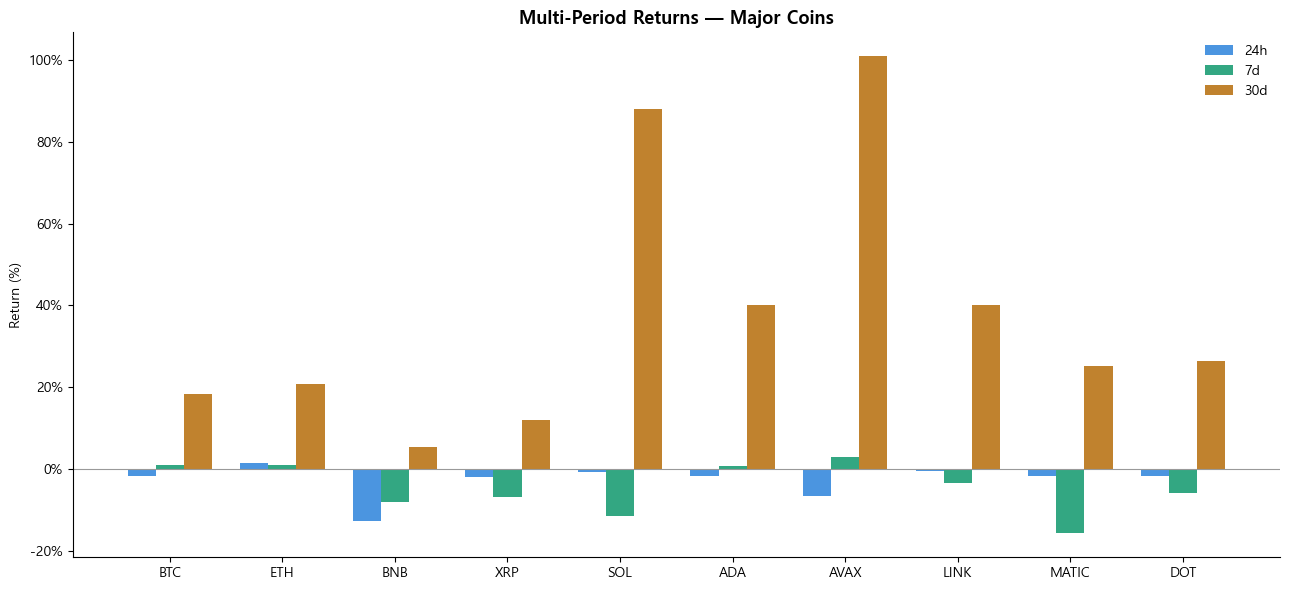

In [56]:
symbols = ["BTC","ETH","BNB","XRP","SOL","ADA","AVAX","LINK","MATIC","DOT"]
sub = (df[df["Symbol"].isin(symbols)]
       .drop_duplicates("Symbol")
       .set_index("Symbol"))
available = [s for s in symbols if s in sub.index]
sub = sub.reindex(available)

cols   = ["24h_pct","7d_pct","30d_pct"]
labels = ["24h","7d","30d"]
colors = [PALETTE["primary"], PALETTE["success"], PALETTE["warning"]]
x      = np.arange(len(available))
width  = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, lbl, color) in enumerate(zip(cols, labels, colors)):
    ax.bar(x + i*width, sub[col].fillna(0), width,
           label=lbl, color=color, edgecolor="none", alpha=0.9)
ax.axhline(0, color="#999", linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(available, fontsize=10)
ax.set_ylabel("Return (%)")
ax.set_title("Multi-Period Returns — Major Coins", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, frameon=False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
plt.tight_layout()
plt.show()

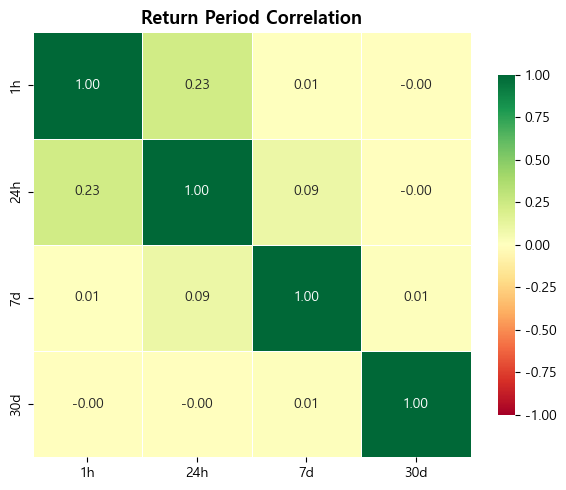

1h↔30d 상관계수: -0.001
→ ≈ 0 : 단기 모멘텀으로 장기 성과 예측 불가


In [57]:
from src.analyzer import return_correlation

corr = return_correlation(df)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, ax=ax, annot=True, fmt=".2f",
            cmap="RdYlGn", center=0, vmin=-1, vmax=1,
            xticklabels=["1h","24h","7d","30d"],
            yticklabels=["1h","24h","7d","30d"],
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8})
ax.set_title("Return Period Correlation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("1h↔30d 상관계수:", corr.loc["1h_pct","30d_pct"])
print("→ ≈ 0 : 단기 모멘텀으로 장기 성과 예측 불가")

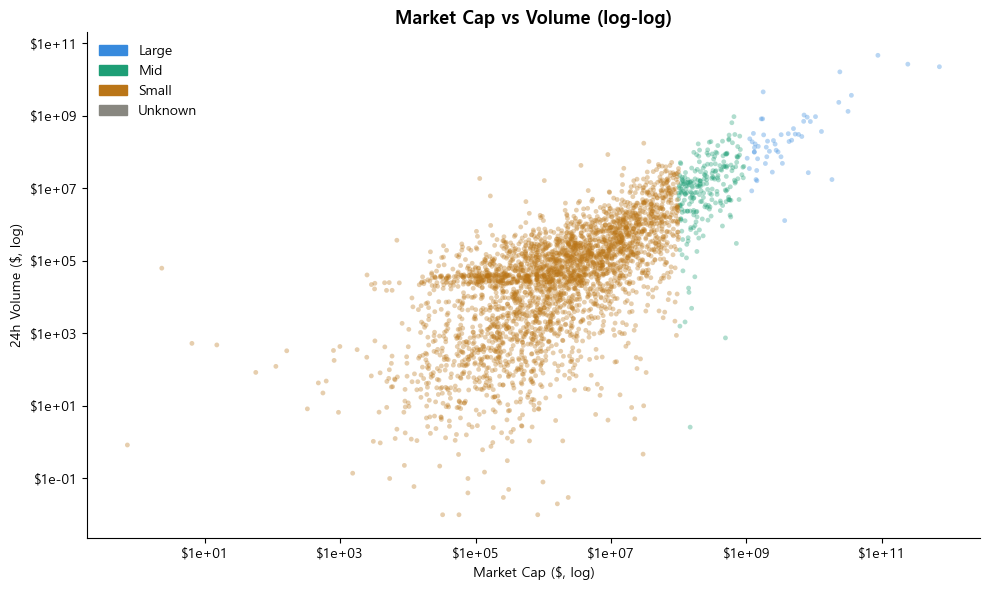

In [66]:
from matplotlib.ticker import LogFormatter

sub = df.dropna(subset=["market_cap","volume"])
sub = sub[(sub["market_cap"] > 0) & (sub["volume"] > 0)]
tier_colors = {
    "Large": PALETTE["primary"], "Mid":     PALETTE["success"],
    "Small": PALETTE["warning"], "Unknown": PALETTE["gray"],
}
c_list = sub["cap_tier"].map(tier_colors).fillna(PALETTE["gray"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(sub["market_cap"], sub["volume"],
           c=c_list, alpha=0.35, s=12, edgecolors="none")
ax.set_xscale("log")
ax.set_yscale("log")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0e}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.0e}"))

ax.set_xlabel("Market Cap ($, log)")
ax.set_ylabel("24h Volume ($, log)")
ax.set_title("Market Cap vs Volume (log-log)", fontsize=13, fontweight="bold")
patches = [mpatches.Patch(color=c, label=l) for l, c in tier_colors.items()]
ax.legend(handles=patches, fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

In [59]:
from src.analyzer import liquidity_analysis, suspicious_liquidity

print("유동성 티어 분포")
print(liquidity_analysis(df).to_string())
print("================================")
print("의심 유동성 코인 (vol/mcap > 100%)")
suspicious_liquidity(df, threshold=1.0, n=10)

유동성 티어 분포
liquidity_tier
낮음(<5%)       2025
보통(5-20%)      758
높음(20-50%)     324
매우높음(>50%)     235
의심 유동성 코인 (vol/mcap > 100%)


,Coin Name,Symbol,price,volume,market_cap,vol_mcap_ratio
0,Artery,ARTR,0.0100,63353.0000,2.3200,27307.3276
1,Structure Finance,STF,0.0100,18863357.0000,115452.0000,163.3870
2,Equalizer,EQZ,0.0100,534.0000,6.4700,82.5348
3,BabySwap,BABY,0.0100,373264.0000,6889.8900,54.1756
4,MrWeb Finance,AMA,NaN,6215999.0000,165596.0000,37.5371
5,WolfSafePoorPeople Polygon,WSPP,NaN,483.0000,15.0800,32.0292
6,Fire Protocol,FIRE,NaN,41121.0000,2497.0500,16.4678
7,TOP Network,TOP,NaN,16516875.0000,1038606.0000,15.9029
8,Silk,SILK,1.0500,43324063.0000,3612472.0000,11.9929
9,Delysium,AGI,0.0300,86276537.0000,9015764.0000,9.5695


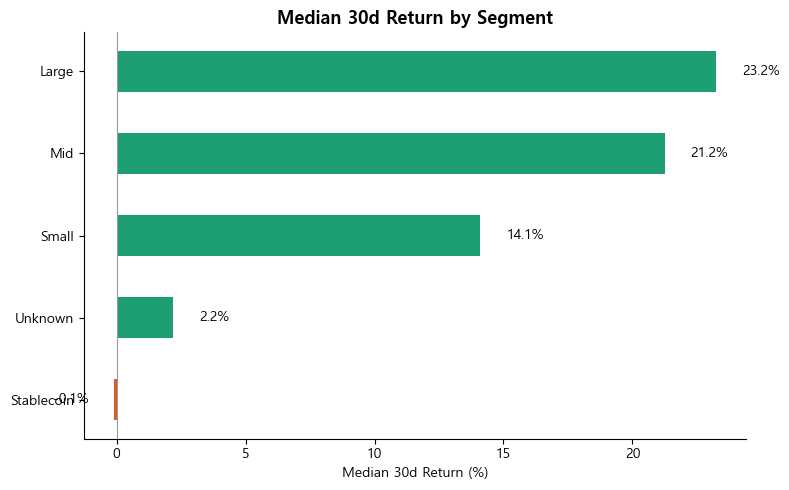

In [60]:
from src.analyzer import segment_analysis

seg    = segment_analysis(df).reset_index()
seg    = seg.sort_values("median_30d", ascending=True)
colors = [COLOR_UP if v >= 0 else COLOR_DOWN for v in seg["median_30d"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(seg["segment"], seg["median_30d"],
               color=colors, edgecolor="none", height=0.5)
for bar, val in zip(bars, seg["median_30d"]):
    xp = val + 1 if val >= 0 else val - 1
    ha = "left"  if val >= 0 else "right"
    ax.text(xp, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", ha=ha, fontsize=10)
ax.axvline(0, color="#999", linewidth=0.8)
ax.set_title("Median 30d Return by Segment", fontsize=13, fontweight="bold")
ax.set_xlabel("Median 30d Return (%)")
plt.tight_layout()
plt.show()

          volatility_1h  volatility_24h
cap_tier                               
Large            0.4380          2.6780
Mid              0.7260          3.8140
Small            1.1850          7.1280
Unknown          2.5410          9.9100


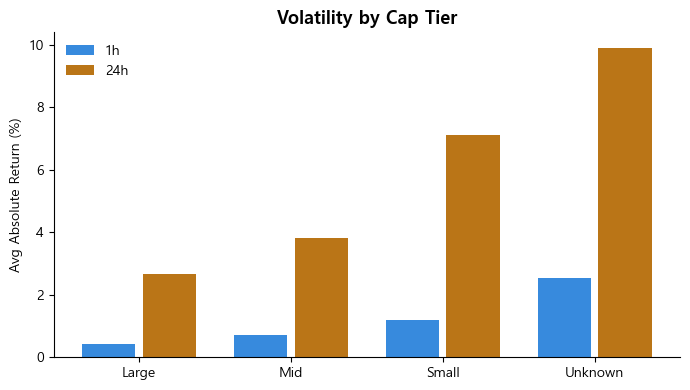

In [61]:
from src.analyzer import volatility_proxy

vol = volatility_proxy(df)
print(vol.to_string())

x = np.arange(len(vol))
plt.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - 0.2, vol["volatility_1h"],  0.35, label="1h",  color=PALETTE["primary"])
ax.bar(x + 0.2, vol["volatility_24h"], 0.35, label="24h", color=PALETTE["warning"])

ax.set_xticks(x)
ax.set_xticklabels(vol.index)
ax.set_ylabel("Avg Absolute Return (%)")
ax.set_title("Volatility by Cap Tier", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

In [62]:
from src.reporter import generate_report

print(generate_report(df))

# Cryptocurrency Market Analysis Report
> 2026-05-06 11:59  |  분석 코인: 4,150개

---
## Executive Summary

| Metric | Value |
|--------|-------|
| Total Market Cap        | **$1442.7B** |
| BTC Dominance           | **49.4%** |
| ETH Dominance           | 16.9% |
| Stablecoin Share        | 8.6% |
| Top-10 Concentration    | 83.3% |
| 30d Median Return       | **+14.1%** |
| % Coins Positive (30d)  | 71.4% |

---
## 1. 30d Return Distribution

| Bucket | Count |
|--------|-------|
| < -50% | 139 |
| -50~0% | 904 |
| 0~50% | 1,813 |
| 50~100% | 388 |
| > 100% | 397 |

---
## 2. Return Summary (excl. Stablecoins)

| Period | Mean | Median | Positive Rate |
|--------|------|--------|---------------|
| 1H | +0.2% | 0.0% | 53.9% |
| 24H | +0.2% | -1.1% | 37.9% |
| 7D | +5.4% | -1.9% | 41.1% |
| 30D | +116.0% | +14.1% | 71.8% |

---
## 3. Segment Analysis

| Segment | Count | Mean 30d | Median 30d |
|---------|-------|----------|------------|
| Large | 50 | +42.8% | +23.2% |
| Mid | 241 | +55.0

In [63]:
from src.reporter import save_report

save_report(df);

[reporter] 저장 → outputs/reports/crypto_analysis_report.md


In [64]:
from src.visualizer import run_all_charts

run_all_charts(df)

  [chart] 01_market_cap_donut.png
  [chart] 02_volume_top10.png
  [chart] 03_return_histogram.png
  [chart] 04_period_returns.png


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


  [chart] 05_correlation_heatmap.png
  [chart] 06_segment_returns.png


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


  [chart] 07_mcap_vs_volume_scatter.png
  [chart] 08_top_gainers.png
  → 8개 차트 완료 → outputs/charts


[WindowsPath('C:/Users/color/Desktop/crypto_analysis/outputs/charts/01_market_cap_donut.png'),
 WindowsPath('C:/Users/color/Desktop/crypto_analysis/outputs/charts/02_volume_top10.png'),
 WindowsPath('C:/Users/color/Desktop/crypto_analysis/outputs/charts/03_return_histogram.png'),
 WindowsPath('C:/Users/color/Desktop/crypto_analysis/outputs/charts/04_period_returns.png'),
 WindowsPath('C:/Users/color/Desktop/crypto_analysis/outputs/charts/05_correlation_heatmap.png'),
 WindowsPath('C:/Users/color/Desktop/crypto_analysis/outputs/charts/06_segment_returns.png'),
 WindowsPath('C:/Users/color/Desktop/crypto_analysis/outputs/charts/07_mcap_vs_volume_scatter.png'),
 WindowsPath('C:/Users/color/Desktop/crypto_analysis/outputs/charts/08_top_gainers.png')]